# SHAP Analysis

Analyzes feature importance using SHAP values. Compares US vs UK models, identifies top features, and examines feature-family contributions with bootstrap confidence intervals.


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# where Notebook 5 saved files
SHAP_DIR = Path("../../reports/stocks/tables/shap")
FIGS_DIR = Path("../../reports/stocks/figures")
FIGS_DIR.mkdir(parents=True, exist_ok=True)

# choose which set to load
RUN_TAGS = ["v3_1b_US", "v3_1b_UK"]   # or just ["v3_1b_US"] while testing

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True


In [23]:
# 1) load & combine all SHAP importance files across folds (per tag)

def load_shap_tables(tag: str):
    imps    = list(SHAP_DIR.glob(f"shap_importance_{tag}_*.parquet"))
    fams    = list(SHAP_DIR.glob(f"shap_families_{tag}_*.parquet"))
    recipes = list(SHAP_DIR.glob(f"shap_recipe_{tag}_*.parquet"))

    if not imps:
        raise FileNotFoundError(f"No shap_importance files found for tag {tag}")

    imp_df = pd.concat([pd.read_parquet(p) for p in imps], ignore_index=True)
    fam_df = pd.concat([pd.read_parquet(p) for p in fams], ignore_index=True) if fams else pd.DataFrame()
    rec_df = pd.concat([pd.read_parquet(p) for p in recipes], ignore_index=True) if recipes else pd.DataFrame()
    return imp_df, fam_df, rec_df

all_sets = {}
for tag in RUN_TAGS:
    try:
        imp, fam, rec = load_shap_tables(tag)
        all_sets[tag] = {"imp": imp, "fam": fam, "rec": rec}
        print(tag, "→", len(imp), "rows (feature importances);", len(fam), "rows (families);", len(rec), "rows (recipe)")
    except FileNotFoundError as e:
        print(f"{e} - skipping {tag}")


v3_1b_US → 228 rows (feature importances); 48 rows (families); 2736 rows (recipe)
v3_1b_UK → 222 rows (feature importances); 48 rows (families); 2664 rows (recipe)



=== Top-15 Features by mean |SHAP| — v3_1b_US ===


,feature,mean_abs_shap
6,gt_ma3,0.060929
10,liquidity_12m,0.056379
32,tracking_error_12,0.047292
35,vol_12,0.038856
36,vol_6,0.035584
34,vix_lvl,0.032567
18,sec_Discretionary,0.031249
11,mom_log_12,0.030439
8,gt_z12,0.029955
3,dist_sma_12,0.029195


   Saved: ../../reports/stocks/figures/shap_top15_features_US.png


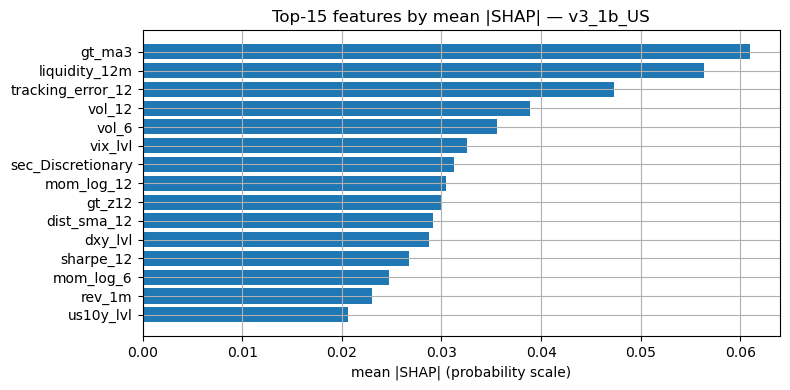


=== Top-15 Features by mean |SHAP| — v3_1b_UK ===


,feature,mean_abs_shap
6,gt_ma3,0.075033
10,liquidity_12m,0.068841
3,dex_usuk,0.058745
34,vol_12,0.038606
33,uk10y_lvl,0.038166
20,sec_Financials,0.030705
22,sec_Industrials,0.026681
8,gt_z12,0.025951
1,brent_d3m,0.025676
32,tracking_error_12,0.025133


   Saved: ../../reports/stocks/figures/shap_top15_features_UK.png


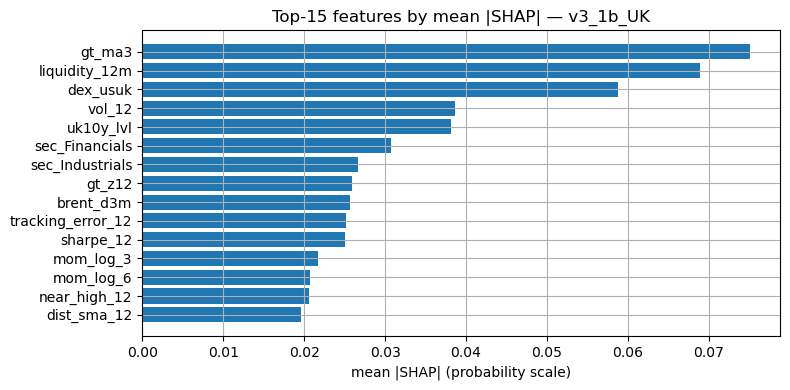


Creating Combined Top-15 SHAP Features (US vs UK)
   Saved: ../../reports/stocks/figures/shap_top15_features_US_UK_combined.png


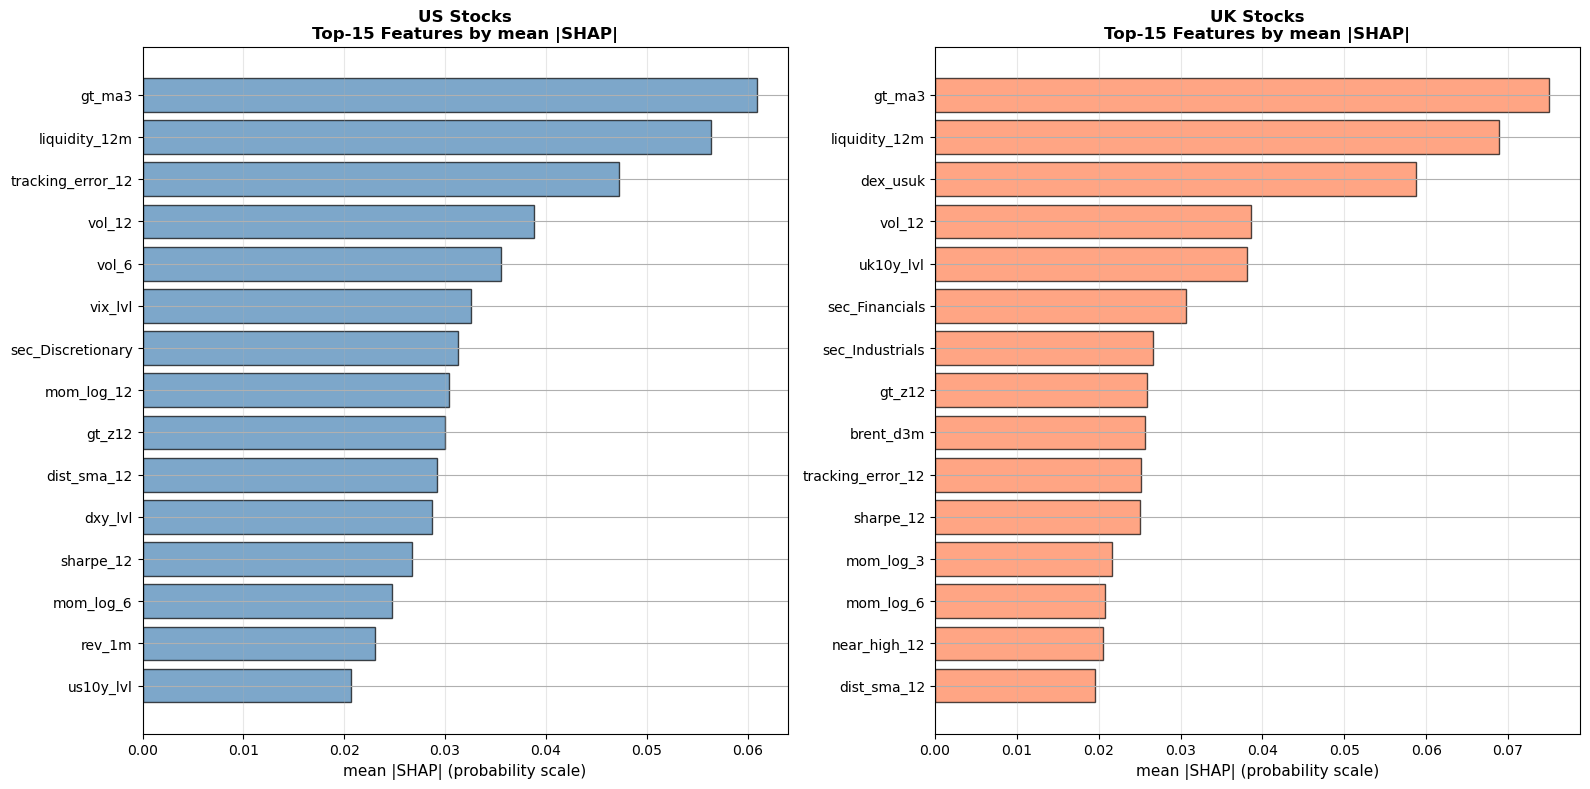

In [25]:
# 2) aggregate feature importances across folds & plot top-k

def agg_feature_importance(imp_df: pd.DataFrame, top_k=15):
    # average mean_abs_shap across folds (group by feature)
    agg = (imp_df.groupby("feature", as_index=False)["mean_abs_shap"].mean()
                 .sort_values("mean_abs_shap", ascending=False))
    return agg.head(top_k)

# Store aggregated data for combined plot
agg_data = {}

for tag, d in all_sets.items():
    agg = agg_feature_importance(d["imp"], top_k=15)
    print(f"\n=== Top-15 Features by mean |SHAP| — {tag} ===")
    display(agg)

    # Store for combined plot
    agg_data[tag] = agg.copy()

    plt.figure()
    plt.barh(agg["feature"][::-1], agg["mean_abs_shap"][::-1])
    plt.title(f"Top-15 features by mean |SHAP| — {tag}")
    plt.xlabel("mean |SHAP| (probability scale)")
    plt.tight_layout()
    fig_path = FIGS_DIR / f"shap_top15_features_{tag.split('_')[-1]}.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f"   Saved: {fig_path}")
    plt.show()

# Create combined figure with two panels (US and UK side-by-side)
if "v3_1b_US" in agg_data and "v3_1b_UK" in agg_data:
    print("\n" + "="*70)
    print("Creating Combined Top-15 SHAP Features (US vs UK)")
    print("="*70)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

    # US panel
    agg_us = agg_data["v3_1b_US"]
    ax1.barh(agg_us["feature"][::-1], agg_us["mean_abs_shap"][::-1],
             color='steelblue', alpha=0.7, edgecolor='black')
    ax1.set_title("US Stocks\nTop-15 Features by mean |SHAP|", fontsize=12, fontweight='bold')
    ax1.set_xlabel("mean |SHAP| (probability scale)", fontsize=11)
    ax1.grid(axis='x', alpha=0.3)

    # UK panel
    agg_uk = agg_data["v3_1b_UK"]
    ax2.barh(agg_uk["feature"][::-1], agg_uk["mean_abs_shap"][::-1],
             color='coral', alpha=0.7, edgecolor='black')
    ax2.set_title("UK Stocks\nTop-15 Features by mean |SHAP|", fontsize=12, fontweight='bold')
    ax2.set_xlabel("mean |SHAP| (probability scale)", fontsize=11)
    ax2.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    fig_path = FIGS_DIR / "shap_top15_features_US_UK_combined.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f"   Saved: {fig_path}")
    plt.show()



=== Feature Families with 95% CI — v3_1b_US ===
(Bootstrap CIs resampled across folds)


,family,mean_abs_shap,ci_lower,ci_upper
7,volatility,0.121732,0.114999,0.127295
6,structure,0.105761,0.096216,0.115336
2,momentum,0.098733,0.093130,0.105524
1,macro,0.094498,0.073805,0.120292
0,google_trends,0.090884,0.084790,0.098837
3,other,0.083142,0.077823,0.088971
4,price_positioning,0.050114,0.045767,0.055012
5,regime,0.016820,0.014511,0.018990



Statistical Significance Check:
   volatility vs structure (overlapping CIs - not significantly different)
   volatility > momentum (non-overlapping CIs)


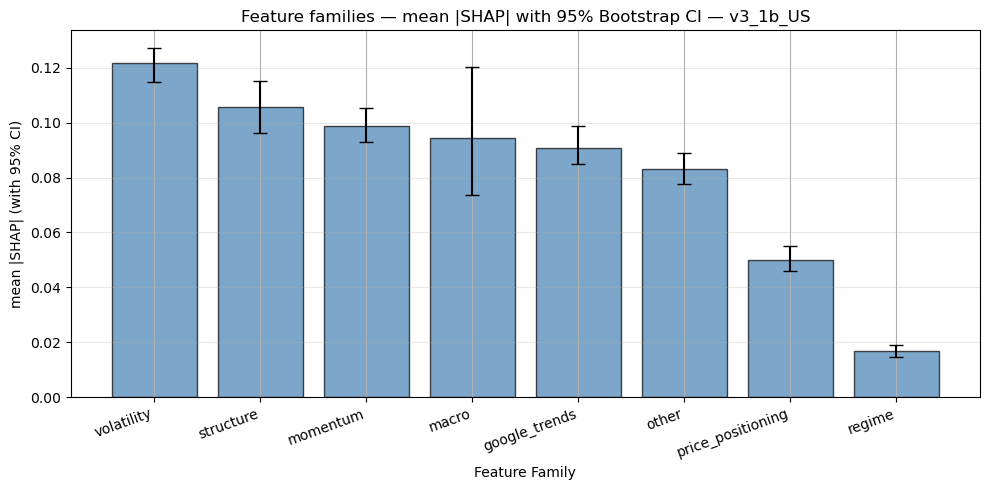


=== Feature Families with 95% CI — v3_1b_UK ===
(Bootstrap CIs resampled across folds)


,family,mean_abs_shap,ci_lower,ci_upper
3,other,0.132000,0.126205,0.138347
6,structure,0.124829,0.121315,0.128148
0,google_trends,0.100984,0.095897,0.106071
1,macro,0.084420,0.072067,0.097753
7,volatility,0.082568,0.075948,0.089272
2,momentum,0.078807,0.073614,0.084952
4,price_positioning,0.045384,0.042136,0.049258
5,regime,0.019274,0.016415,0.022422



Statistical Significance Check:
   other vs structure (overlapping CIs - not significantly different)
   other > google_trends (non-overlapping CIs)


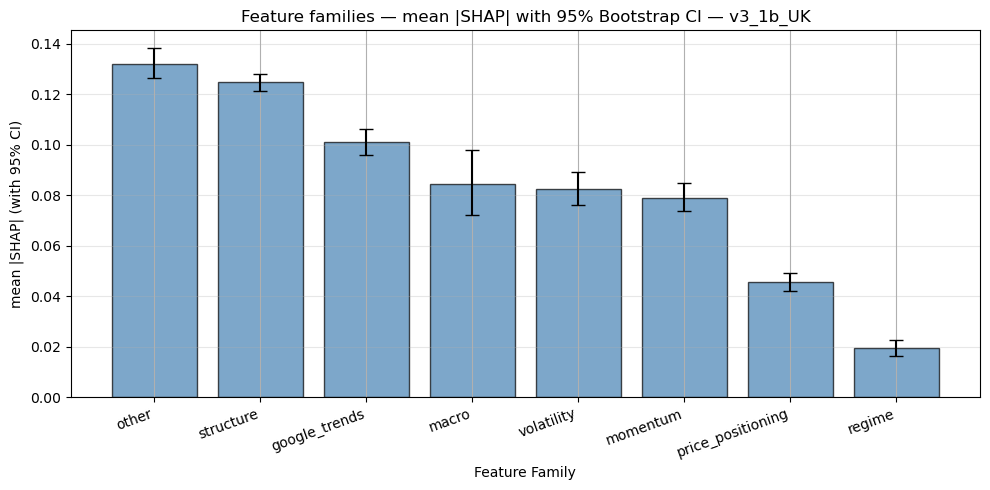


=== US vs UK Comparison (95% Bootstrap CIs) ===

Statistically Significant Differences:
   US volatility > UK volatility (non-overlapping CIs)
   UK structure > US structure (non-overlapping CIs)
   US momentum > UK momentum (non-overlapping CIs)
   UK other > US other (non-overlapping CIs)

Comparison Table:


,family,mean_abs_shap_US,ci_lower_US,ci_upper_US,mean_abs_shap_UK,ci_lower_UK,ci_upper_UK
7,volatility,0.12173,0.11500,0.12729,0.08257,0.07595,0.08927
6,structure,0.10576,0.09622,0.11534,0.12483,0.12131,0.12815
2,momentum,0.09873,0.09313,0.10552,0.07881,0.07361,0.08495
1,macro,0.09450,0.07380,0.12029,0.08442,0.07207,0.09775
0,google_trends,0.09088,0.08479,0.09884,0.10098,0.09590,0.10607
3,other,0.08314,0.07782,0.08897,0.13200,0.12620,0.13835
4,price_positioning,0.05011,0.04577,0.05501,0.04538,0.04214,0.04926
5,regime,0.01682,0.01451,0.01899,0.01927,0.01642,0.02242



   Saved: ../../reports/stocks/figures/shap_families_comparison_US_vs_UK.png


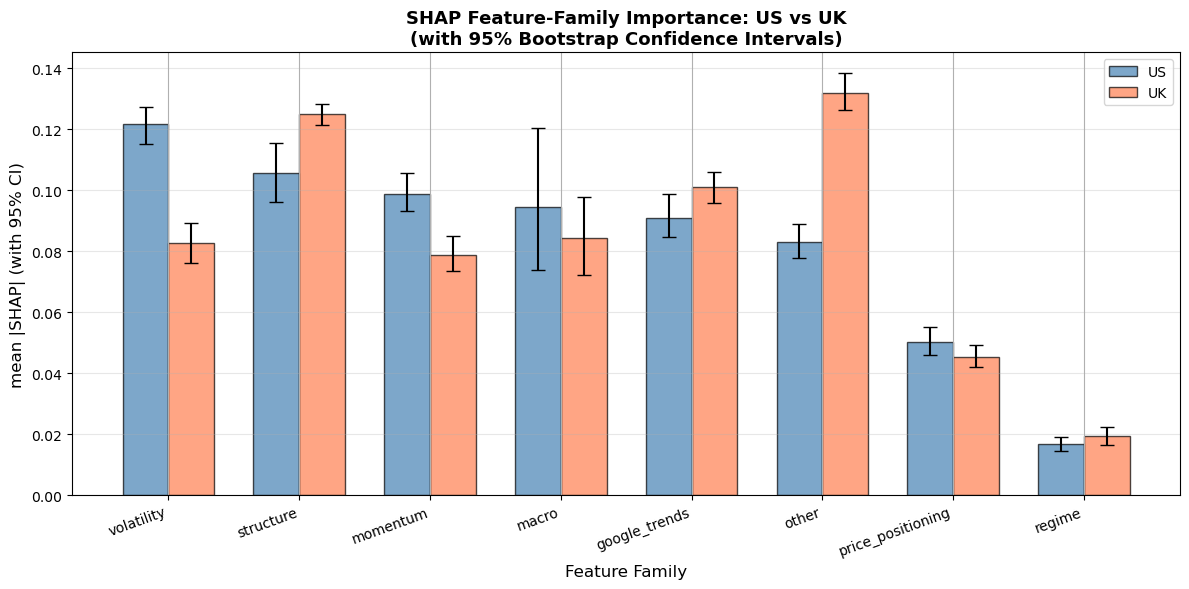

In [27]:
# 3) aggregate families across folds & plot WITH BOOTSTRAP CONFIDENCE INTERVALS

def agg_families_with_ci(fam_df: pd.DataFrame, n_bootstrap=1000, ci_level=0.95):
    """
    Aggregate families with bootstrap confidence intervals.
    Bootstrap resamples across folds to get uncertainty estimates.
    """
    if fam_df.empty:
        return pd.DataFrame(columns=["family", "mean_abs_shap", "ci_lower", "ci_upper"])

    # Get fold-level data (group by family and fold)
    fold_data = fam_df.groupby(["family", "train_end", "val_year"], as_index=False)["mean_abs_shap"].first()

    # Bootstrap CI for each family
    results = []
    for family in fold_data["family"].unique():
        family_folds = fold_data[fold_data["family"] == family]["mean_abs_shap"].values

        if len(family_folds) < 2:
            # Not enough folds for bootstrap
            mean_val = family_folds[0] if len(family_folds) == 1 else np.nan
            results.append({
                "family": family,
                "mean_abs_shap": mean_val,
                "ci_lower": mean_val,
                "ci_upper": mean_val
            })
            continue

        # Bootstrap: resample folds with replacement, compute mean
        bootstrap_means = []
        np.random.seed(42)  # For reproducibility
        for _ in range(n_bootstrap):
            resampled = np.random.choice(family_folds, size=len(family_folds), replace=True)
            bootstrap_means.append(np.mean(resampled))

        # Compute CI
        alpha = 1 - ci_level
        ci_lower = np.percentile(bootstrap_means, 100 * alpha / 2)
        ci_upper = np.percentile(bootstrap_means, 100 * (1 - alpha / 2))
        mean_val = np.mean(family_folds)

        results.append({
            "family": family,
            "mean_abs_shap": mean_val,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper
        })

    agg = pd.DataFrame(results).sort_values("mean_abs_shap", ascending=False)
    return agg

# Store US and UK results for comparison
fam_agg_us = None
fam_agg_uk = None

for tag, d in all_sets.items():
    fam_agg = agg_families_with_ci(d["fam"], n_bootstrap=1000, ci_level=0.95)
    print(f"\n=== Feature Families with 95% CI — {tag} ===")
    print("(Bootstrap CIs resampled across folds)")
    display(fam_agg)

    # Store for comparison
    if tag == "v3_1b_US":
        fam_agg_us = fam_agg.copy()
    elif tag == "v3_1b_UK":
        fam_agg_uk = fam_agg.copy()

    # Check for non-overlapping CIs (statistical significance)
    if len(fam_agg) > 1:
        print(f"\nStatistical Significance Check:")
        top_fam = fam_agg.iloc[0]
        for i in range(1, min(3, len(fam_agg))):
            comp_fam = fam_agg.iloc[i]
            # Check if CIs don't overlap
            if top_fam["ci_lower"] > comp_fam["ci_upper"]:
                print(f"   {top_fam['family']} > {comp_fam['family']} (non-overlapping CIs)")
            elif comp_fam["ci_lower"] > top_fam["ci_upper"]:
                print(f"   {comp_fam['family']} > {top_fam['family']} (non-overlapping CIs)")
            else:
                print(f"   {top_fam['family']} vs {comp_fam['family']} (overlapping CIs - not significantly different)")

    if not fam_agg.empty:
        plt.figure(figsize=(10, 5))
        x_pos = np.arange(len(fam_agg))
        means = fam_agg["mean_abs_shap"].values
        ci_lower = fam_agg["ci_lower"].values
        ci_upper = fam_agg["ci_upper"].values
        errors = [means - ci_lower, ci_upper - means]

        bars = plt.bar(x_pos, means, yerr=errors, capsize=5, alpha=0.7, color='steelblue', edgecolor='black')
        plt.xlabel("Feature Family")
        plt.ylabel("mean |SHAP| (with 95% CI)")
        plt.title(f"Feature families — mean |SHAP| with 95% Bootstrap CI — {tag}")
        plt.xticks(x_pos, fam_agg["family"], rotation=20, ha="right")
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

# Compare US vs UK after both are computed
if fam_agg_us is not None and fam_agg_uk is not None:
    print(f"\n{'='*70}")
    print("=== US vs UK Comparison (95% Bootstrap CIs) ===")
    print(f"{'='*70}")
    comparison = fam_agg_us.merge(
        fam_agg_uk, on="family", suffixes=("_US", "_UK"), how="outer"
    ).fillna(0)
    comparison = comparison.sort_values("mean_abs_shap_US", ascending=False)

    # Check for significant differences
    sig_diffs = []
    for _, row in comparison.iterrows():
        us_lower = row["ci_lower_US"]
        us_upper = row["ci_upper_US"]
        uk_lower = row["ci_lower_UK"]
        uk_upper = row["ci_upper_UK"]

        # Non-overlapping CIs = statistically significant difference
        if us_lower > uk_upper:
            sig_diffs.append(f"US {row['family']} > UK {row['family']} (non-overlapping CIs)")
        elif uk_lower > us_upper:
            sig_diffs.append(f"UK {row['family']} > US {row['family']} (non-overlapping CIs)")

    if sig_diffs:
        print("\nStatistically Significant Differences:")
        for diff in sig_diffs:
            print(f"   {diff}")
    else:
        print("\nNo statistically significant differences (all CIs overlap)")

    print(f"\nComparison Table:")
    display(comparison[["family", "mean_abs_shap_US", "ci_lower_US", "ci_upper_US",
                       "mean_abs_shap_UK", "ci_lower_UK", "ci_upper_UK"]].round(5))

    # Create comparison plot
    fig, ax = plt.subplots(figsize=(12, 6))
    x_pos = np.arange(len(comparison))
    width = 0.35

    bars1 = ax.bar(x_pos - width/2, comparison["mean_abs_shap_US"].values, width,
                   yerr=[comparison["mean_abs_shap_US"].values - comparison["ci_lower_US"].values,
                         comparison["ci_upper_US"].values - comparison["mean_abs_shap_US"].values],
                   label='US', alpha=0.7, color='steelblue', edgecolor='black', capsize=5)
    bars2 = ax.bar(x_pos + width/2, comparison["mean_abs_shap_UK"].values, width,
                   yerr=[comparison["mean_abs_shap_UK"].values - comparison["ci_lower_UK"].values,
                         comparison["ci_upper_UK"].values - comparison["mean_abs_shap_UK"].values],
                   label='UK', alpha=0.7, color='coral', edgecolor='black', capsize=5)

    ax.set_xlabel("Feature Family", fontsize=12)
    ax.set_ylabel("mean |SHAP| (with 95% CI)", fontsize=12)
    ax.set_title("SHAP Feature-Family Importance: US vs UK\n(with 95% Bootstrap Confidence Intervals)", fontsize=13, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(comparison["family"], rotation=20, ha="right")
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()

    fig_path = FIGS_DIR / "shap_families_comparison_US_vs_UK.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f"\n   Saved: {fig_path}")
    plt.show()


In [29]:
# 4) "recipe for success" table

def recipe_table(rec_df: pd.DataFrame, top_k=15):
    if rec_df.empty:
        return pd.DataFrame(columns=["feature","mean_shap","mean_val"])
    g = (rec_df.groupby("feature", as_index=False)[["mean_shap","mean_val"]]
               .mean())
    # absolute SHAP to rank importance, but keep signed mean_shap in the table
    g["rank_key"] = g["mean_shap"].abs()
    g = g.sort_values("rank_key", ascending=False).drop(columns=["rank_key"])
    return g.head(top_k)

for tag, d in all_sets.items():
    rec_tbl = recipe_table(d["rec"], top_k=20)
    print(f"\n=== Recipe for success — {tag} ===")
    print("(Top-decile predicted winners: avg signed SHAP + avg raw feature value)")
    display(rec_tbl)



=== Recipe for success — v3_1b_US ===
(Top-decile predicted winners: avg signed SHAP + avg raw feature value)


,feature,mean_shap,mean_val
6,gt_ma3,0.042813,24.760058
10,liquidity_12m,0.037718,18.857814
18,sec_Discretionary,0.031458,0.300000
35,vol_12,0.023593,0.080337
17,sec_CommServices,0.020757,0.264583
32,tracking_error_12,0.017907,0.062398
11,mom_log_12,0.015725,0.049913
8,gt_z12,0.015033,0.019844
5,dxy_lvl,-0.014063,115.298729
34,vix_lvl,0.013097,19.934861



=== Recipe for success — v3_1b_UK ===
(Top-decile predicted winners: avg signed SHAP + avg raw feature value)


,feature,mean_shap,mean_val
6,gt_ma3,0.103047,14.298657
10,liquidity_12m,0.066599,18.459306
3,dex_usuk,-0.042608,1.302236
33,uk10y_lvl,0.034494,1.178218
34,vol_12,0.024997,0.090408
22,sec_Industrials,0.022500,0.403935
8,gt_z12,0.013216,-0.019536
20,sec_Financials,0.012855,0.086806
28,sharpe_12,0.012309,-0.027175
12,mom_log_3,0.010920,-0.036363



=== Top-15 Recurrence Heatmap — v3_1b_US ===
Features appearing in top-15 across 6 folds
Features shown: 19 (those appearing at least once)

Recurrence Summary:
   Always in top-15 (6/6 folds): 11 features
   Often in top-15 (≥4/6 folds): 15 features
   Sometimes in top-15 (1-3/6 folds): 4 features

   Most stable features (appear in all folds):
      tracking_error_12
      gt_z12
      mom_log_12
      sharpe_12
      vol_6
      vol_12
      rev_1m
      dist_sma_12
      liquidity_12m
      sec_Discretionary


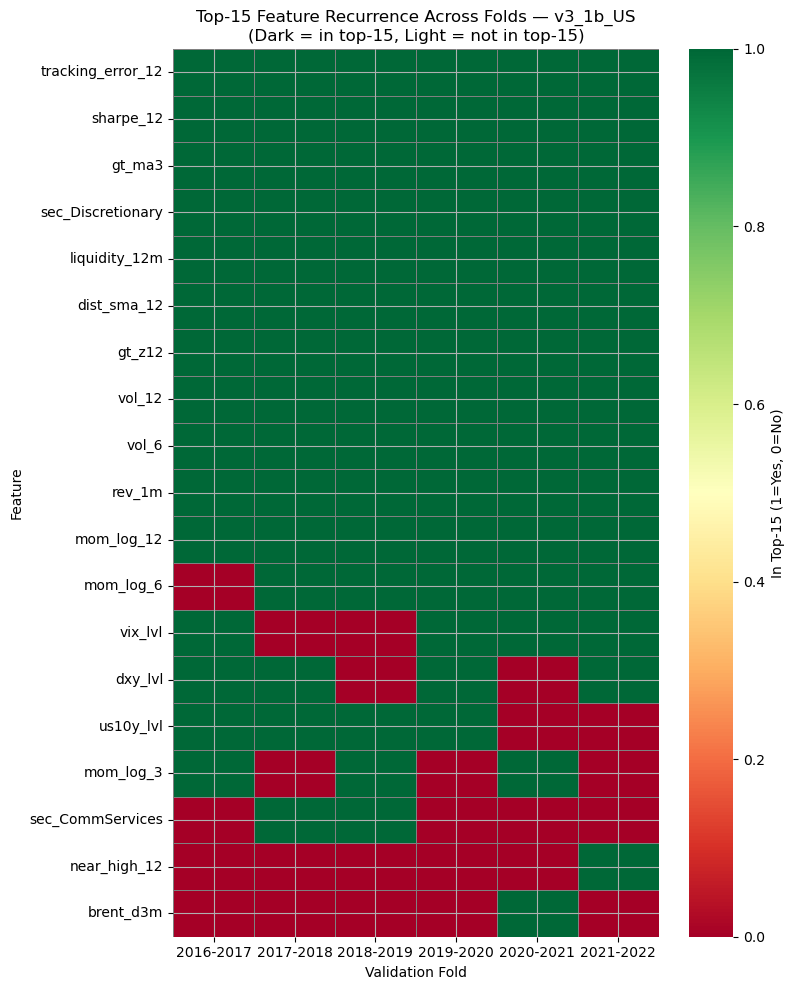


Recurrence Count Table (how many folds each feature appears in top-15):


,feature,folds_in_top15,pct_folds
0,tracking_error_12,6,100.0
1,gt_z12,6,100.0
2,mom_log_12,6,100.0
3,sharpe_12,6,100.0
4,vol_6,6,100.0
5,vol_12,6,100.0
6,rev_1m,6,100.0
7,dist_sma_12,6,100.0
8,liquidity_12m,6,100.0
9,sec_Discretionary,6,100.0



=== Top-15 Recurrence Heatmap — v3_1b_UK ===
Features appearing in top-15 across 6 folds
Features shown: 19 (those appearing at least once)

Recurrence Summary:
   Always in top-15 (6/6 folds): 9 features
   Often in top-15 (≥4/6 folds): 15 features
   Sometimes in top-15 (1-3/6 folds): 4 features

   Most stable features (appear in all folds):
      gt_z12
      gt_ma3
      dex_usuk
      uk10y_lvl
      vol_12
      sharpe_12
      sec_Industrials
      sec_Financials
      liquidity_12m


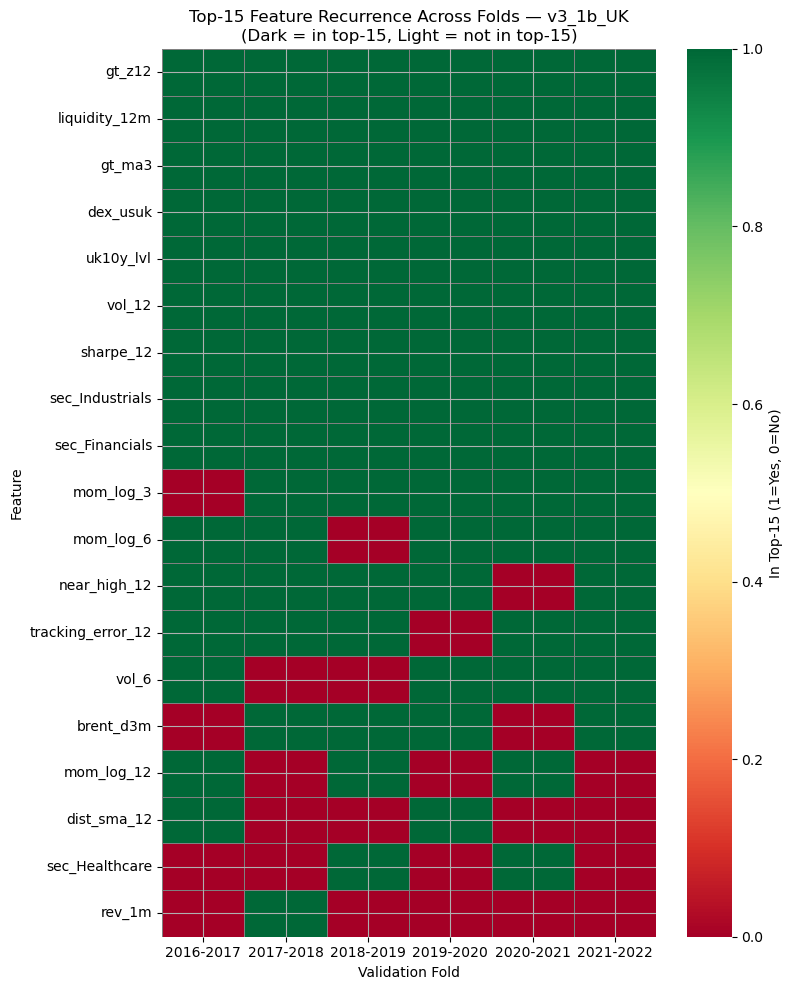


Recurrence Count Table (how many folds each feature appears in top-15):


,feature,folds_in_top15,pct_folds
0,gt_z12,6,100.0
1,gt_ma3,6,100.0
2,dex_usuk,6,100.0
3,uk10y_lvl,6,100.0
4,vol_12,6,100.0
5,sharpe_12,6,100.0
6,sec_Industrials,6,100.0
7,sec_Financials,6,100.0
8,liquidity_12m,6,100.0
9,near_high_12,5,83.3


In [31]:
# 5) Top-15 Recurrence Heatmap (shows stability across folds)

import seaborn as sns

def create_recurrence_heatmap(imp_df: pd.DataFrame, top_k=15):
    """
    Create a heatmap showing which features appear in top-k across folds.
    Rows = features, Columns = folds, Values = 1 if in top-k, 0 otherwise
    """
    # Get top-k per fold
    folds = imp_df[['train_end', 'val_year']].drop_duplicates().sort_values(['train_end', 'val_year'])

    # Create matrix: features × folds
    all_features = imp_df['feature'].unique()
    recurrence_matrix = []

    for _, fold_row in folds.iterrows():
        fold_data = imp_df[
            (imp_df['train_end'] == fold_row['train_end']) &
            (imp_df['val_year'] == fold_row['val_year'])
        ]
        top_k_features = fold_data.nlargest(top_k, 'mean_abs_shap')['feature'].values

        # Binary: 1 if in top-k, 0 otherwise
        fold_vector = [1 if feat in top_k_features else 0 for feat in all_features]
        recurrence_matrix.append(fold_vector)

    # Create DataFrame
    recurrence_df = pd.DataFrame(
        recurrence_matrix,
        index=[f"{int(row['train_end'])}-{int(row['val_year'])}" for _, row in folds.iterrows()],
        columns=all_features
    ).T  # Transpose: features as rows, folds as columns

    # Keep only features that appear at least once in top-k
    recurrence_df = recurrence_df[recurrence_df.sum(axis=1) > 0]

    # Sort by total recurrence (most frequent first)
    recurrence_df['total'] = recurrence_df.sum(axis=1)
    recurrence_df = recurrence_df.sort_values('total', ascending=False).drop(columns=['total'])

    return recurrence_df

for tag, d in all_sets.items():
    heatmap_data = create_recurrence_heatmap(d["imp"], top_k=15)

    print(f"\n=== Top-15 Recurrence Heatmap — {tag} ===")
    print(f"Features appearing in top-15 across {len(heatmap_data.columns)} folds")
    print(f"Features shown: {len(heatmap_data)} (those appearing at least once)")

    # Show summary stats
    print(f"\nRecurrence Summary:")
    recurrence_counts = heatmap_data.sum(axis=1).sort_values(ascending=False)
    print(f"   Always in top-15 (6/6 folds): {len(recurrence_counts[recurrence_counts == 6])} features")
    print(f"   Often in top-15 (≥4/6 folds): {len(recurrence_counts[recurrence_counts >= 4])} features")
    print(f"   Sometimes in top-15 (1-3/6 folds): {len(recurrence_counts[recurrence_counts < 4])} features")

    # Show most stable features
    print(f"\n   Most stable features (appear in all folds):")
    stable = recurrence_counts[recurrence_counts == len(heatmap_data.columns)]
    for feat in stable.head(10).index:
        print(f"      {feat}")

    # Create heatmap
    plt.figure(figsize=(8, max(10, len(heatmap_data) * 0.4)))
    sns.heatmap(
        heatmap_data,
        annot=False,
        cmap='RdYlGn',
        cbar_kws={'label': 'In Top-15 (1=Yes, 0=No)'},
        linewidths=0.5,
        linecolor='gray',
        vmin=0,
        vmax=1
    )
    plt.title(f"Top-15 Feature Recurrence Across Folds — {tag}\n(Dark = in top-15, Light = not in top-15)")
    plt.xlabel("Validation Fold")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    # Also show table of recurrence counts
    print(f"\nRecurrence Count Table (how many folds each feature appears in top-15):")
    rec_table = pd.DataFrame({
        'feature': recurrence_counts.index,
        'folds_in_top15': recurrence_counts.values,
        'pct_folds': (recurrence_counts.values / len(heatmap_data.columns) * 100).round(1)
    })
    display(rec_table.head(20))


BINNED SHAP VS VALUE PLOTS
These plots show the relationship between feature values and SHAP contributions.
Negative slope = contrarian (higher feature value → lower probability)
Positive slope = momentum-following (higher feature value → higher probability)


=== v3_1b_US — Top 5 Features by Importance ===

Plotting binned relationships for: mom_log_6, rev_1m, vol_6, gt_z12
   Saved: ../../reports/stocks/figures/shap_binned_US_mom_log_6.png


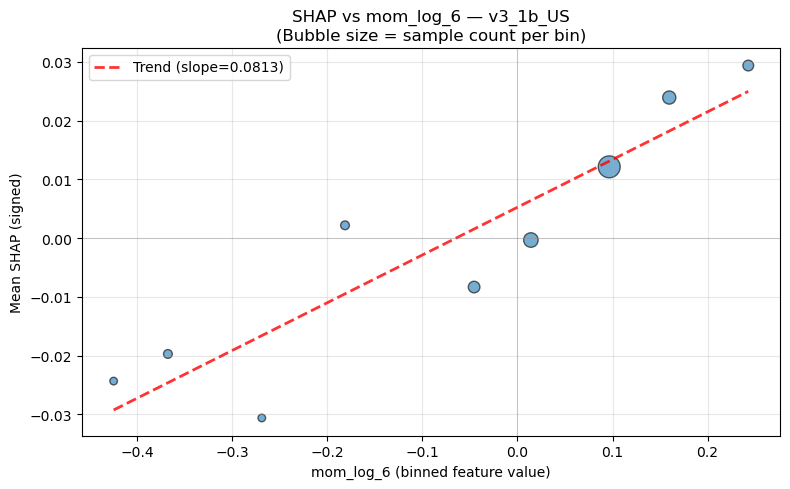


Interpretation for mom_log_6:
   Positive relationship: Higher mom_log_6 → Higher probability (slope=0.0813)
   Bins: 9, Total samples: 72
   Saved: ../../reports/stocks/figures/shap_binned_US_rev_1m.png


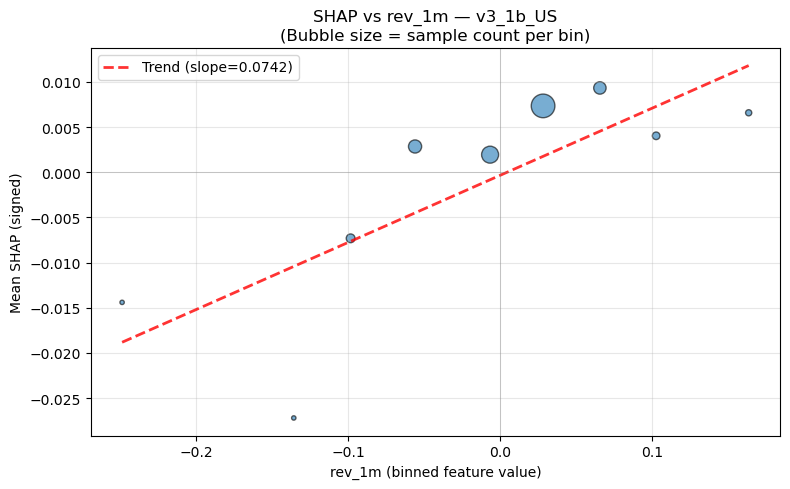


Interpretation for rev_1m:
   Positive relationship: Higher rev_1m → Higher probability (slope=0.0742)
   Bins: 9, Total samples: 72
   Saved: ../../reports/stocks/figures/shap_binned_US_vol_6.png


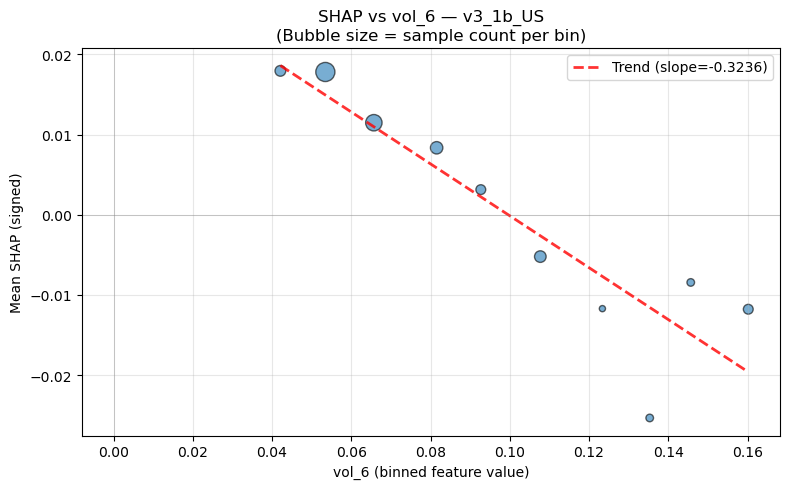


Interpretation for vol_6:
   Negative relationship (CONTRARIAN): Higher vol_6 → Lower probability (slope=-0.3236)
   Bins: 10, Total samples: 72
   Saved: ../../reports/stocks/figures/shap_binned_US_gt_z12.png


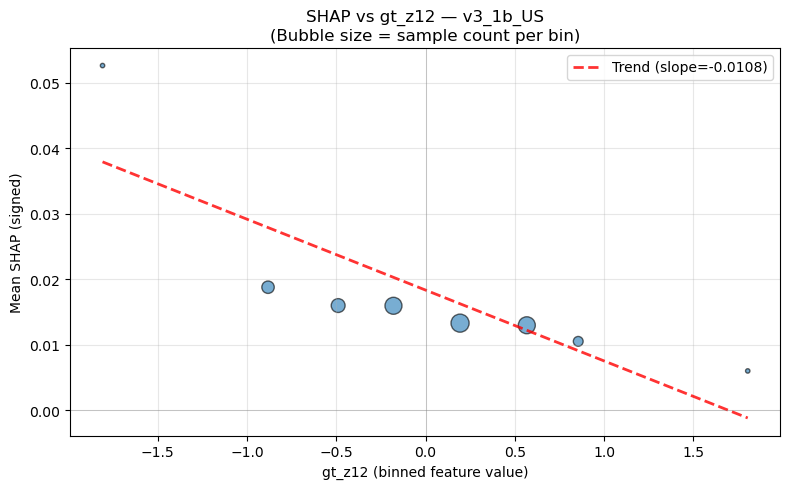


Interpretation for gt_z12:
   Negative relationship (CONTRARIAN): Higher gt_z12 → Lower probability (slope=-0.0108)
   Bins: 8, Total samples: 72

=== v3_1b_UK — Top 5 Features by Importance ===

Plotting binned relationships for: dex_usuk, mom_log_6, rev_1m, vol_6
   Saved: ../../reports/stocks/figures/shap_binned_UK_dex_usuk.png


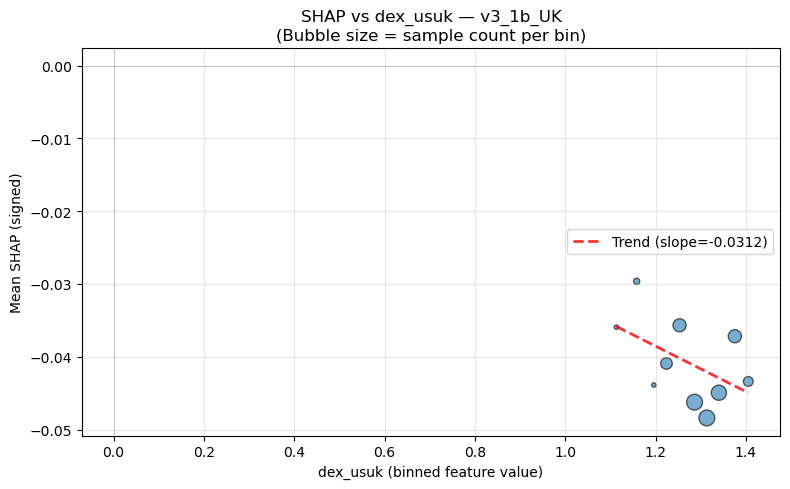


Interpretation for dex_usuk:
   Negative relationship (CONTRARIAN): Higher dex_usuk → Lower probability (slope=-0.0312)
   Bins: 10, Total samples: 72
   Saved: ../../reports/stocks/figures/shap_binned_UK_mom_log_6.png


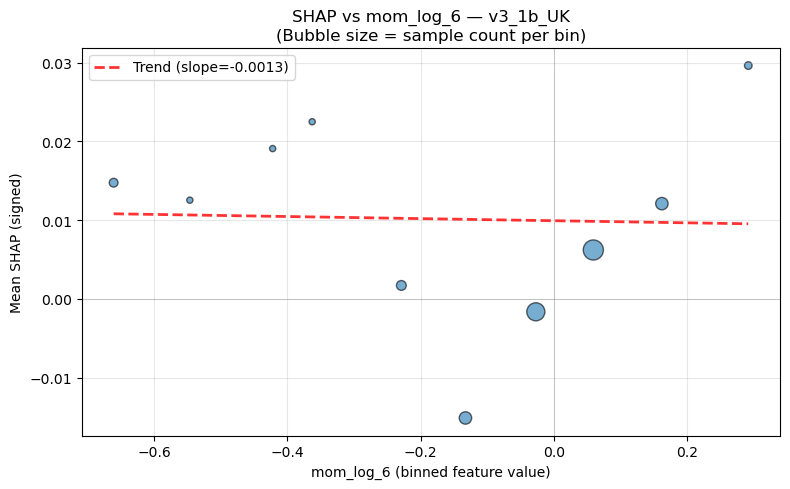


Interpretation for mom_log_6:
   Negative relationship (CONTRARIAN): Higher mom_log_6 → Lower probability (slope=-0.0013)
   Bins: 10, Total samples: 72
   Saved: ../../reports/stocks/figures/shap_binned_UK_rev_1m.png


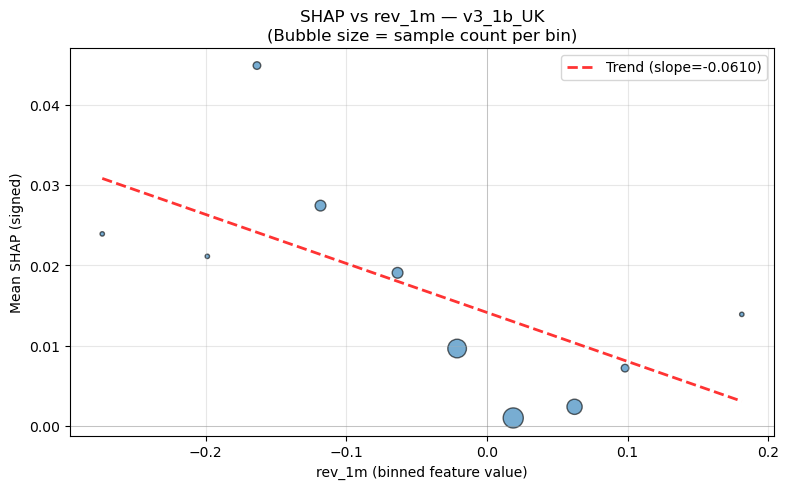


Interpretation for rev_1m:
   Negative relationship (CONTRARIAN): Higher rev_1m → Lower probability (slope=-0.0610)
   Bins: 10, Total samples: 72
   Saved: ../../reports/stocks/figures/shap_binned_UK_vol_6.png


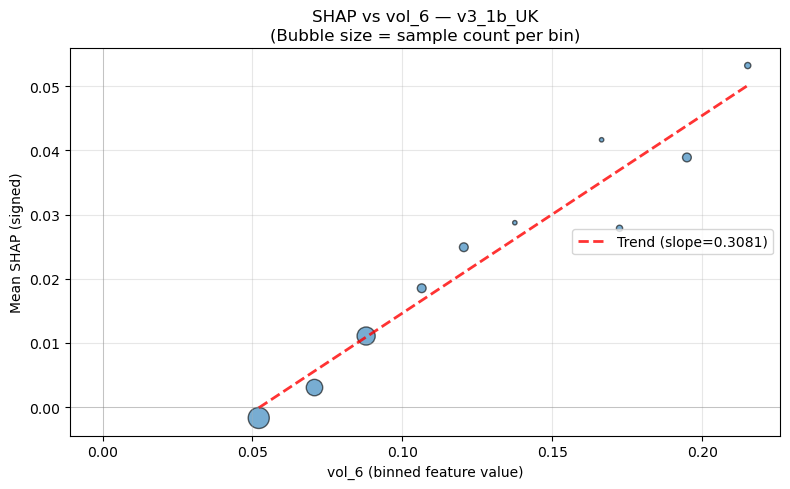


Interpretation for vol_6:
   Positive relationship: Higher vol_6 → Higher probability (slope=0.3081)
   Bins: 10, Total samples: 72


In [33]:
# 6) Binned SHAP vs Value Plots (shows directionality and mechanism)

def plot_binned_shap_vs_value(rec_df: pd.DataFrame, feature: str, n_bins=10, tag: str = ""):
    """
    Create binned plot showing relationship between feature values and SHAP contributions.
    Bins feature values and computes mean SHAP per bin.
    """
    # Filter to feature
    feat_data = rec_df[rec_df['feature'] == feature].copy()

    if len(feat_data) == 0:
        print(f"No data for feature: {feature}")
        return

    # Bin by feature value
    feat_data['bin'] = pd.cut(feat_data['mean_val'], bins=n_bins, labels=False, duplicates='drop')
    bin_stats = feat_data.groupby('bin').agg({
        'mean_shap': 'mean',
        'mean_val': ['mean', 'min', 'max', 'count']
    }).reset_index()

    # Flatten column names
    bin_stats.columns = ['bin', 'mean_shap', 'mean_val', 'val_min', 'val_max', 'count']
    bin_stats = bin_stats.dropna()

    if len(bin_stats) < 2:
        print(f"Not enough bins for feature: {feature}")
        return

    # Create plot
    fig, ax = plt.subplots(figsize=(8, 5))

    # Plot mean SHAP vs bin center (mean feature value)
    ax.scatter(bin_stats['mean_val'], bin_stats['mean_shap'],
               s=bin_stats['count'] * 10, alpha=0.6, edgecolors='black', linewidth=1)

    # Add trend line
    z = np.polyfit(bin_stats['mean_val'], bin_stats['mean_shap'], 1)
    p = np.poly1d(z)
    ax.plot(bin_stats['mean_val'], p(bin_stats['mean_val']),
           "r--", alpha=0.8, linewidth=2, label=f'Trend (slope={z[0]:.4f})')

    ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

    ax.set_xlabel(f'{feature} (binned feature value)')
    ax.set_ylabel('Mean SHAP (signed)')
    ax.set_title(f'SHAP vs {feature} — {tag}\n(Bubble size = sample count per bin)')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()

    # Save figure with appropriate filename
    region = tag.split('_')[-1] if tag else ""
    fig_filename = f"shap_binned_{region}_{feature}.png"
    fig_path = FIGS_DIR / fig_filename
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f"   Saved: {fig_path}")
    plt.show()

    # Print interpretation
    slope = z[0]
    print(f"\nInterpretation for {feature}:")
    if slope > 0.001:
        print(f"   Positive relationship: Higher {feature} → Higher probability (slope={slope:.4f})")
    elif slope < -0.001:
        print(f"   Negative relationship (CONTRARIAN): Higher {feature} → Lower probability (slope={slope:.4f})")
    else:
        print(f"   Weak relationship: slope={slope:.4f} (close to zero)")
    print(f"   Bins: {len(bin_stats)}, Total samples: {feat_data['mean_val'].count()}")

# Select key features to plot (top features that might show interesting patterns)
print("="*70)
print("BINNED SHAP VS VALUE PLOTS")
print("="*70)
print("These plots show the relationship between feature values and SHAP contributions.")
print("Negative slope = contrarian (higher feature value → lower probability)")
print("Positive slope = momentum-following (higher feature value → higher probability)")
print()

# Get top features from importance
for tag, d in all_sets.items():
    top_features = d["imp"].groupby("feature", as_index=False)["mean_abs_shap"].mean().sort_values("mean_abs_shap", ascending=False).head(5)

    print(f"\n{'='*70}")
    print(f"=== {tag} — Top 5 Features by Importance ===")
    print(f"{'='*70}")

    # Plot key features that might show interesting patterns
    # For US: plot mom_log_6 and rev_1m (as referenced in LaTeX)
    # For UK: plot dex_usuk (as referenced in LaTeX)
    if tag == "v3_1b_US":
        key_features = ['mom_log_6', 'rev_1m', 'vol_6', 'gt_z12']
    elif tag == "v3_1b_UK":
        key_features = ['dex_usuk', 'mom_log_6', 'rev_1m', 'vol_6']
    else:
        key_features = ['mom_log_6', 'rev_1m', 'vol_6', 'dex_usuk', 'gt_z12', 'liquidity_12m']

    available_features = [f for f in key_features if f in d["rec"]['feature'].unique()]

    if not available_features:
        print("No key features found in recipe data")
        continue

    print(f"\nPlotting binned relationships for: {', '.join(available_features[:4])}")

    for feat in available_features[:4]:  # Plot top 4
        plot_binned_shap_vs_value(d["rec"], feat, n_bins=10, tag=tag)


Creating Figure 3.1: Stock Universe Composition
    Saved: ../../reports/stocks/figures/fig_3_1_universe_composition.png


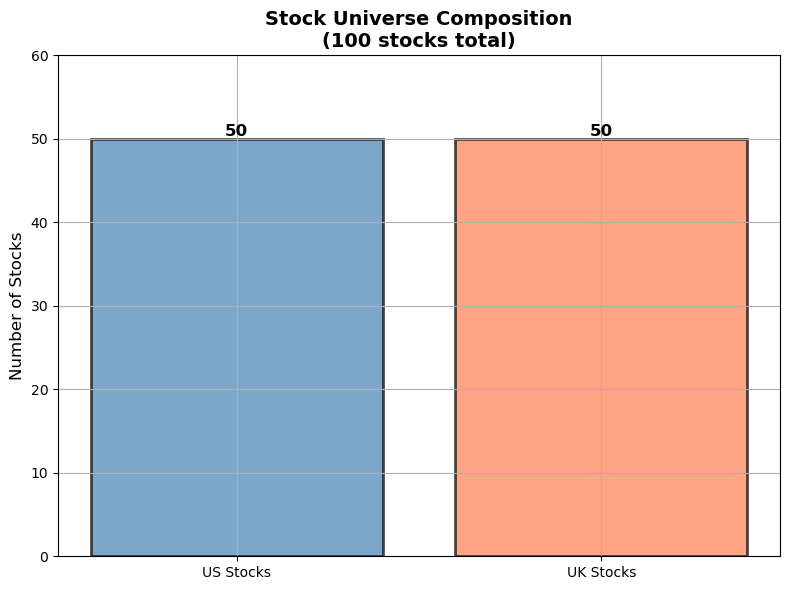


Creating Figure 3.2: Excess Returns Distribution
    Saved: ../../reports/stocks/figures/fig_3_2_excess_returns_distribution.png


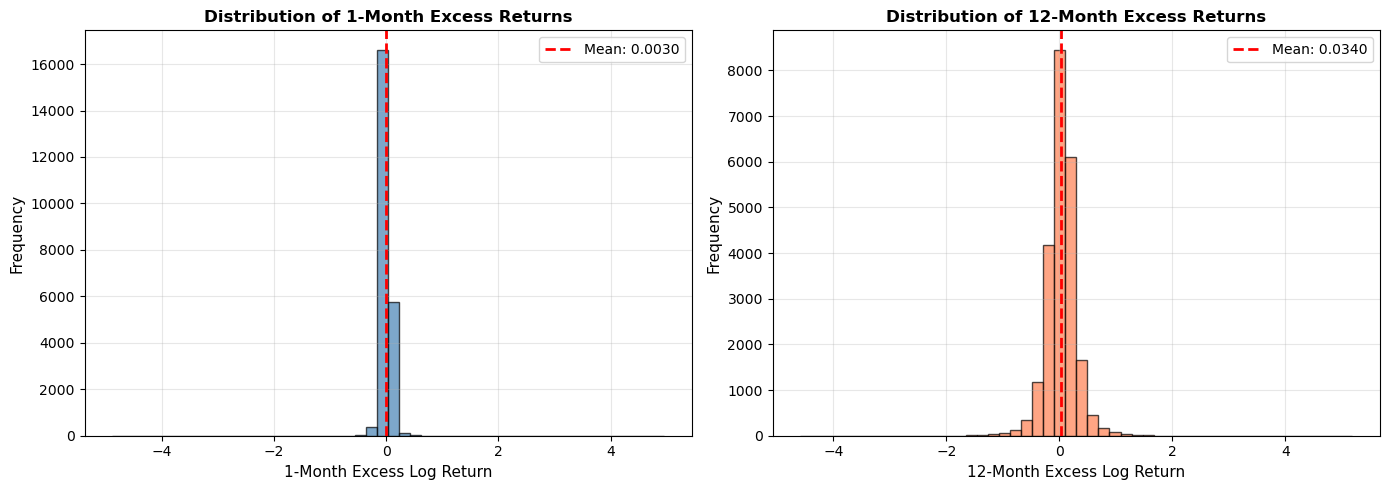


Creating Figure 4.1: Feature Family Overview
    Saved: ../../reports/stocks/figures/fig_4_1_feature_family_overview.png


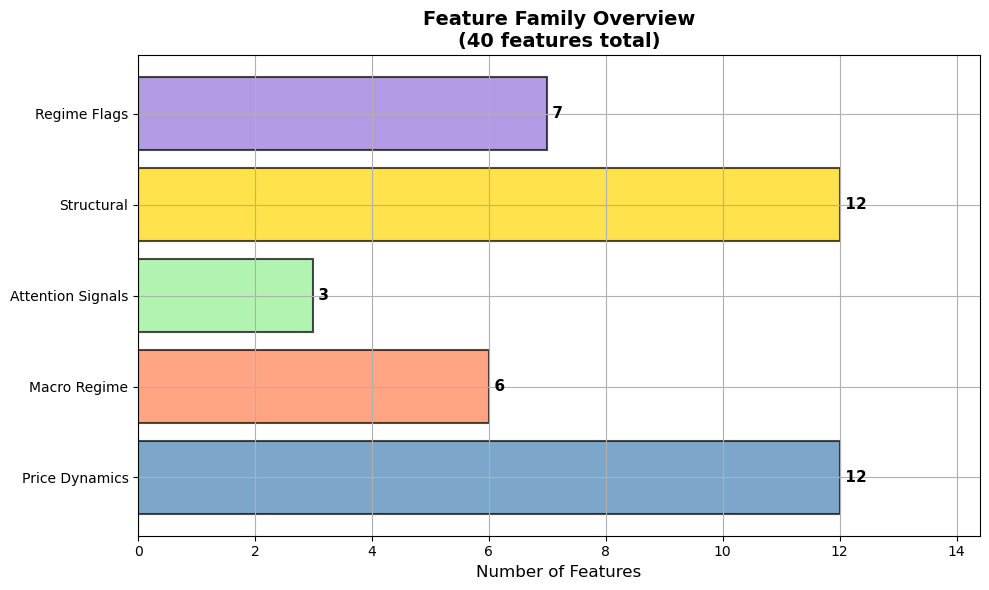


Creating Figure 4.2: Macro Feature Time Series
    Saved: ../../reports/stocks/figures/fig_4_2_macro_time_series.png


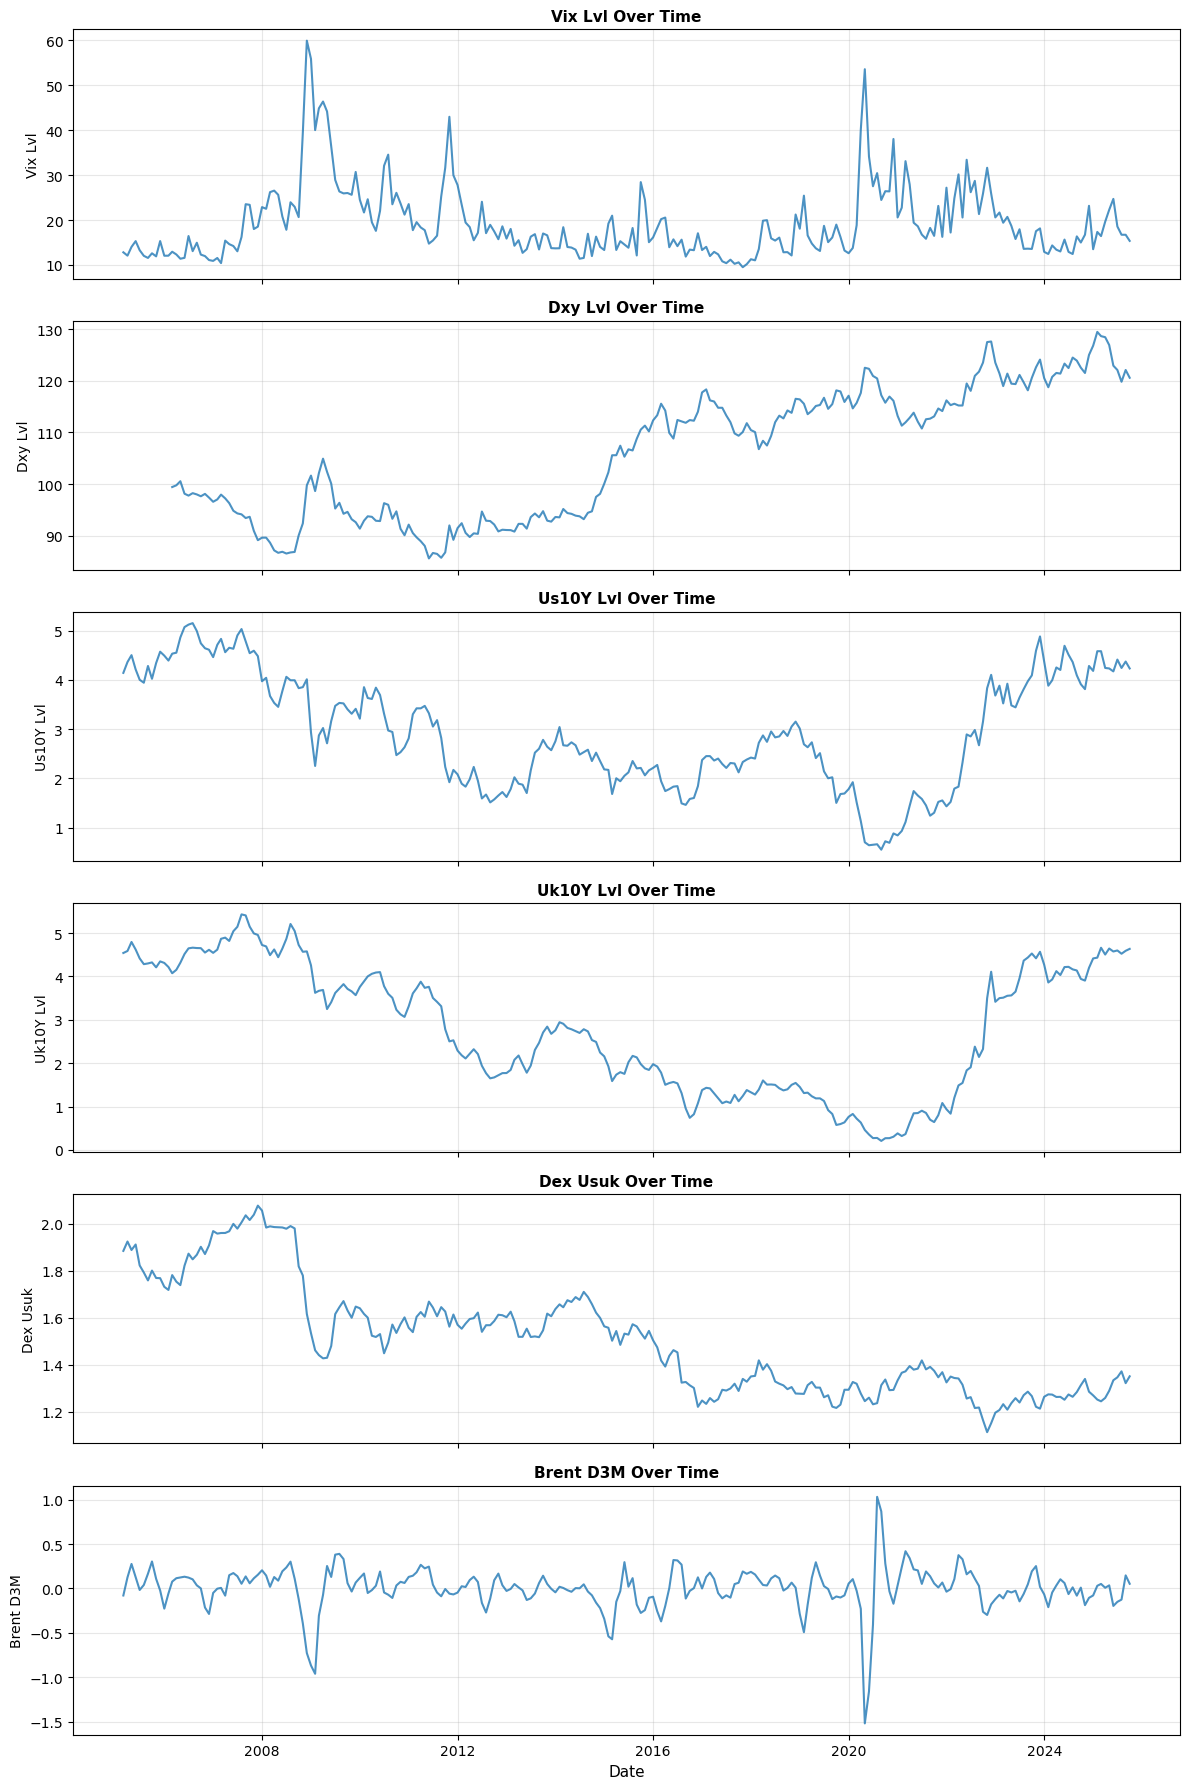


figures created successfully


In [34]:
# 7) Additional figures for dissertation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load data for additional figures
DATA_PATH = Path("../data/interim/features_stocks_v3_1b.parquet")
TARGETS_PATH = Path("../data/processed/stocks_monthly_targets_splits_1b.parquet")

if DATA_PATH.exists():
    df = pd.read_parquet(DATA_PATH)
    df["date"] = pd.to_datetime(df["date"])

    # Figure 3.1: Stock Universe Composition
    print("="*70)
    print("Creating Figure 3.1: Stock Universe Composition")
    print("="*70)

    us_stocks = df[df["country_UK"] == 0]["ticker"].nunique()
    uk_stocks = df[df["country_UK"] == 1]["ticker"].nunique()

    fig, ax = plt.subplots(figsize=(8, 6))
    bars = ax.bar(["US Stocks", "UK Stocks"], [us_stocks, uk_stocks],
                  color=['steelblue', 'coral'], alpha=0.7, edgecolor='black', linewidth=2)
    ax.set_ylabel("Number of Stocks", fontsize=12)
    ax.set_title("Stock Universe Composition\n(100 stocks total)", fontsize=14, fontweight='bold')
    ax.set_ylim(0, max(us_stocks, uk_stocks) * 1.2)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.tight_layout()
    fig_path = FIGS_DIR / "fig_3_1_universe_composition.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f"    Saved: {fig_path}")
    plt.show()

    # Figure 3.2: Excess Returns Distribution
    if TARGETS_PATH.exists():
        print("\n" + "="*70)
        print("Creating Figure 3.2: Excess Returns Distribution")
        print("="*70)

        targets = pd.read_parquet(TARGETS_PATH)
        targets["date"] = pd.to_datetime(targets["date"])

        # Merge to get excess returns
        merged = df.merge(targets[["date", "ticker", "Y_REG", "excess_log_next"]],
                         on=["date", "ticker"], how="inner")

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        # 1-month excess returns
        ex_1m = merged["excess_log_next"].dropna()
        ax1.hist(ex_1m, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
        ax1.axvline(ex_1m.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {ex_1m.mean():.4f}')
        ax1.set_xlabel("1-Month Excess Log Return", fontsize=11)
        ax1.set_ylabel("Frequency", fontsize=11)
        ax1.set_title("Distribution of 1-Month Excess Returns", fontsize=12, fontweight='bold')
        ax1.legend()
        ax1.grid(alpha=0.3)

        # 12-month excess returns
        ex_12m = merged["Y_REG"].dropna()
        ax2.hist(ex_12m, bins=50, alpha=0.7, color='coral', edgecolor='black')
        ax2.axvline(ex_12m.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {ex_12m.mean():.4f}')
        ax2.set_xlabel("12-Month Excess Log Return", fontsize=11)
        ax2.set_ylabel("Frequency", fontsize=11)
        ax2.set_title("Distribution of 12-Month Excess Returns", fontsize=12, fontweight='bold')
        ax2.legend()
        ax2.grid(alpha=0.3)

        plt.tight_layout()
        fig_path = FIGS_DIR / "fig_3_2_excess_returns_distribution.png"
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f"    Saved: {fig_path}")
        plt.show()

    # Figure 4.1: Feature Family Overview
    print("\n" + "="*70)
    print("Creating Figure 4.1: Feature Family Overview")
    print("="*70)

    # Define feature families
    feature_families = {
        'Price Dynamics': ['mom_log_3', 'mom_log_6', 'mom_log_12', 'rev_1m',
                          'vol_6', 'vol_12', 'sharpe_12',
                          'drawdown_12', 'near_high_12', 'dist_sma_12', 'tracking_error_12', 'liquidity_12m'],
        'Macro Regime': ['vix_lvl', 'dxy_lvl', 'us10y_lvl', 'uk10y_lvl', 'dex_usuk', 'brent_d3m'],
        'Attention Signals': ['gt_ma3', 'gt_z12', 'gt_spike'],
        'Structural': ['country_UK', 'sec_CommServices', 'sec_Discretionary', 'sec_Energy',
                      'sec_Financials', 'sec_Healthcare', 'sec_Industrials', 'sec_Materials',
                      'sec_RealEstate', 'sec_Staples', 'sec_Tech', 'sec_Utilities'],
        'Regime Flags': ['bear_tape', 'high_vix', 'oil_shock', 'strong_dollar', 'strong_gbp',
                        'strong_gbp_uk', 'vol_regime']
    }

    family_counts = {fam: len(feats) for fam, feats in feature_families.items()}

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(list(family_counts.keys()), list(family_counts.values()),
                  color=['steelblue', 'coral', 'lightgreen', 'gold', 'mediumpurple'],
                  alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.set_xlabel("Number of Features", fontsize=12)
    ax.set_title("Feature Family Overview\n(40 features total)", fontsize=14, fontweight='bold')
    ax.set_xlim(0, max(family_counts.values()) * 1.2)

    # Add value labels
    for i, (fam, count) in enumerate(family_counts.items()):
        ax.text(count, i, f' {count}', va='center', fontsize=11, fontweight='bold')

    plt.tight_layout()
    fig_path = FIGS_DIR / "fig_4_1_feature_family_overview.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f"    Saved: {fig_path}")
    plt.show()

    # Figure 4.2: Macro Feature Time Series
    print("\n" + "="*70)
    print("Creating Figure 4.2: Macro Feature Time Series")
    print("="*70)

    macro_features = ['vix_lvl', 'dxy_lvl', 'us10y_lvl', 'uk10y_lvl', 'dex_usuk', 'brent_d3m']
    available_macro = [f for f in macro_features if f in df.columns]

    if available_macro:
        # Get unique dates and macro values (they should be same across stocks per date)
        macro_data = df[['date'] + available_macro].drop_duplicates('date').sort_values('date')

        fig, axes = plt.subplots(len(available_macro), 1, figsize=(12, 3*len(available_macro)), sharex=True)
        if len(available_macro) == 1:
            axes = [axes]

        for i, feat in enumerate(available_macro):
            axes[i].plot(macro_data['date'], macro_data[feat], linewidth=1.5, alpha=0.8)
            axes[i].set_ylabel(feat.replace('_', ' ').title(), fontsize=10)
            axes[i].grid(alpha=0.3)
            axes[i].set_title(f"{feat.replace('_', ' ').title()} Over Time", fontsize=11, fontweight='bold')

        axes[-1].set_xlabel("Date", fontsize=11)
        plt.tight_layout()
        fig_path = FIGS_DIR / "fig_4_2_macro_time_series.png"
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f"    Saved: {fig_path}")
        plt.show()

    print("\nfigures created successfully")
else:
    print(f"Data file not found: {DATA_PATH}")
    print(" Skipping additional figure generation.")
